## Dataset: controlled affine teacher

Start with a linear teacher with no bias first:

$$
x \sim \mathcal{U}([0,1]^{d_{\text{in}}})
$$

$$
y = A x
$$

Use:

$$
d_{\text{in}}=4,
\qquad
d_{\text{out}}=2.
$$

We use this exact teacher matrix:

$$
A =
\begin{bmatrix}
1.25 & -0.75 & 0.50 & 0.20 \\
-0.40 & 0.90 & 1.10 & -0.60
\end{bmatrix}.
$$

So if

$$
x =
\begin{bmatrix}
x_1\\x_2\\x_3\\x_4
\end{bmatrix},
$$

then
$$
y_1
=
1.25x_1-0.75x_2+0.50x_3+0.20x_4,
$$
$$
y_2
=
-0.40x_1+0.90x_2+1.10x_3-0.60x_4.
$$

This matrix is good because:

* coefficients are not all positive,
* output dimensions mix input dimensions differently,
* values are moderate,
* the task is exactly solvable,
* the Hessian is analytically simple.

For the second dataset variant, add bias:
$$
y=Ax+b
$$
with
$$
b=
\begin{bmatrix}
0.35\\
-0.25
\end{bmatrix}.
$$

But I would start with $b=0$. Bias makes the Hessian slightly less clean because the bias parameters have different curvature behavior.

In [1]:
import enabol

[INFO] - ENABOL imported successfully! Version: 0.1.0, URL: https://manuelblancovalentin.github.io/ENABOL/


AffineDataset(
 [Input] X: 
    Shape: (1000, 4)
    Dtype: DataType.D2_FLOAT
    X <- Uniform(-1, 1)
 [Output] Y: 
    Shape: (1000, 2)
    Dtype: DataType.D2_FLOAT
    Y <- X @ A.T + b
 ---------
  A = [[ 1.25 -0.75  0.5   0.2 ]
       [-0.4   0.9   1.1  -0.6 ]]
  b = [0. 0.]
----------
Analytic Hessian:
  Lambda max: 1.0721
  Eta max: 1.8654
)


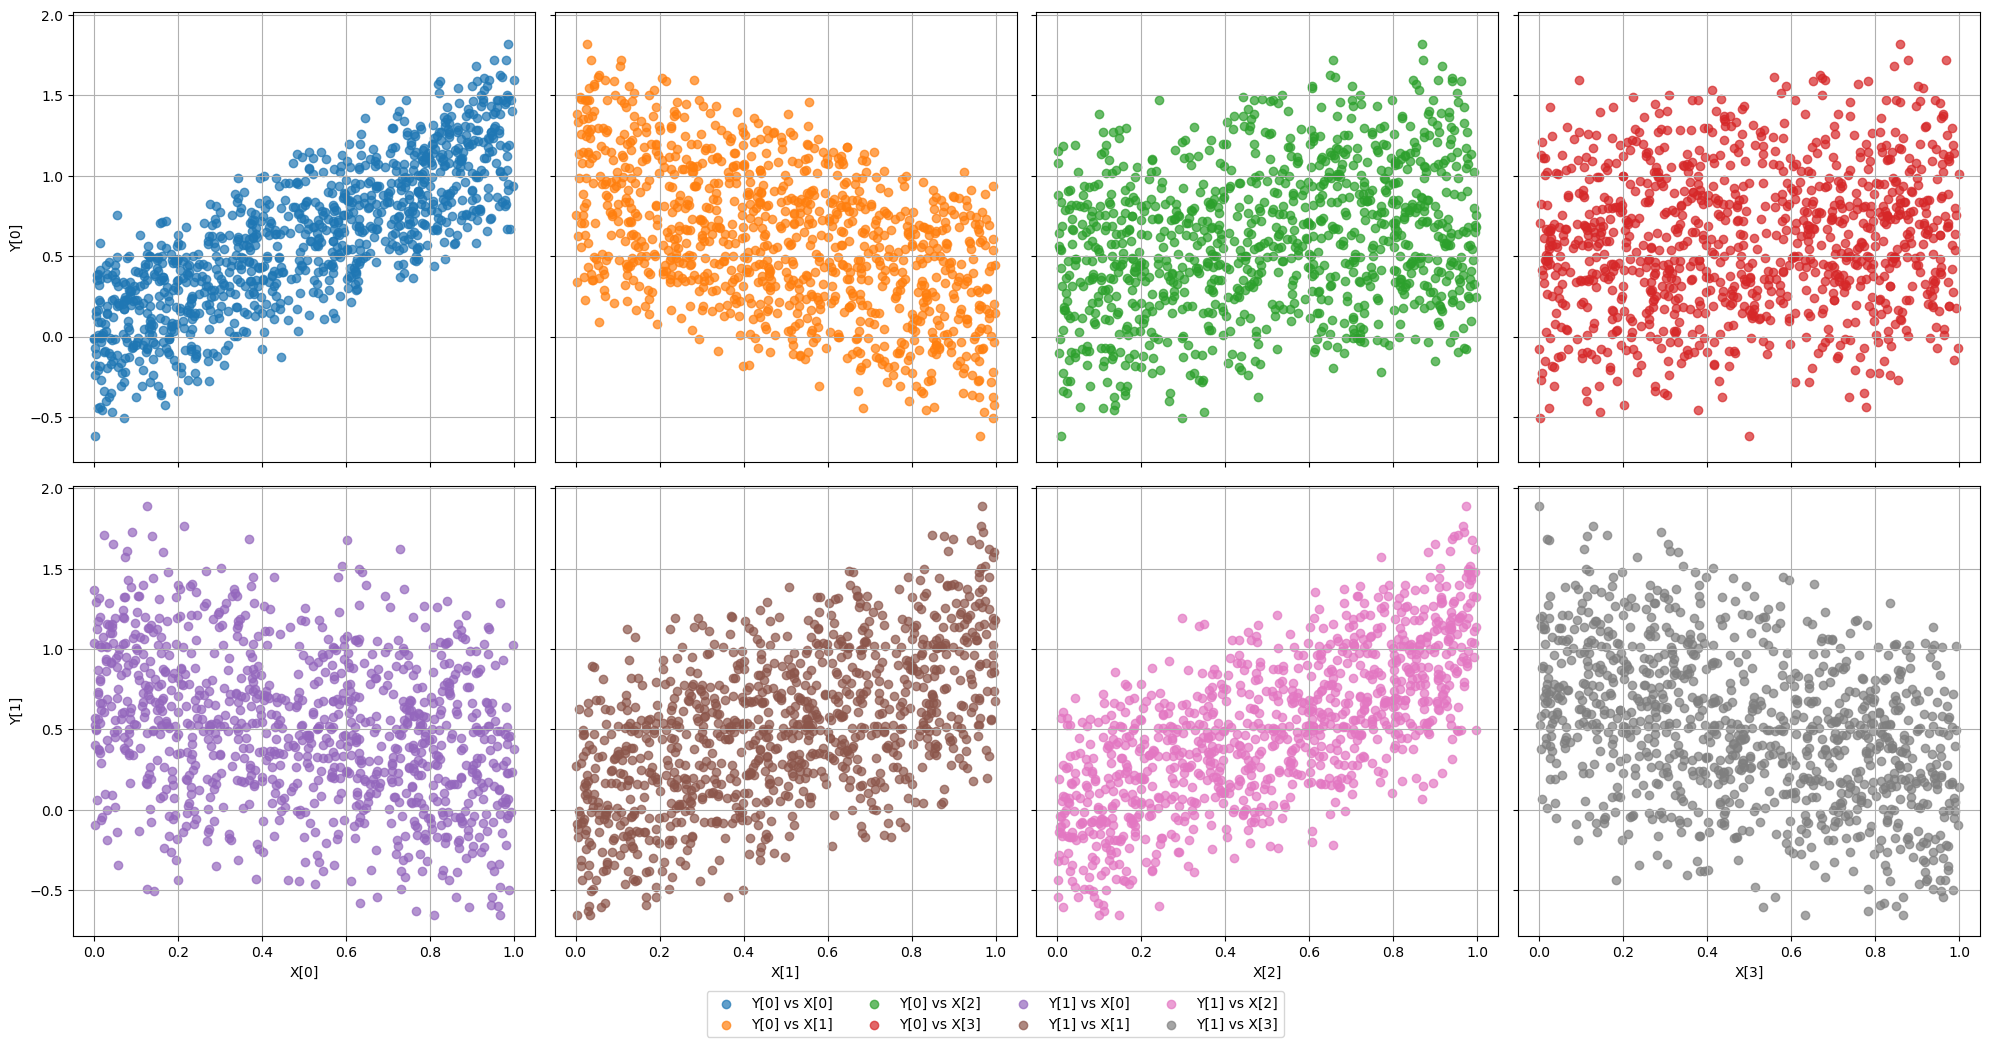

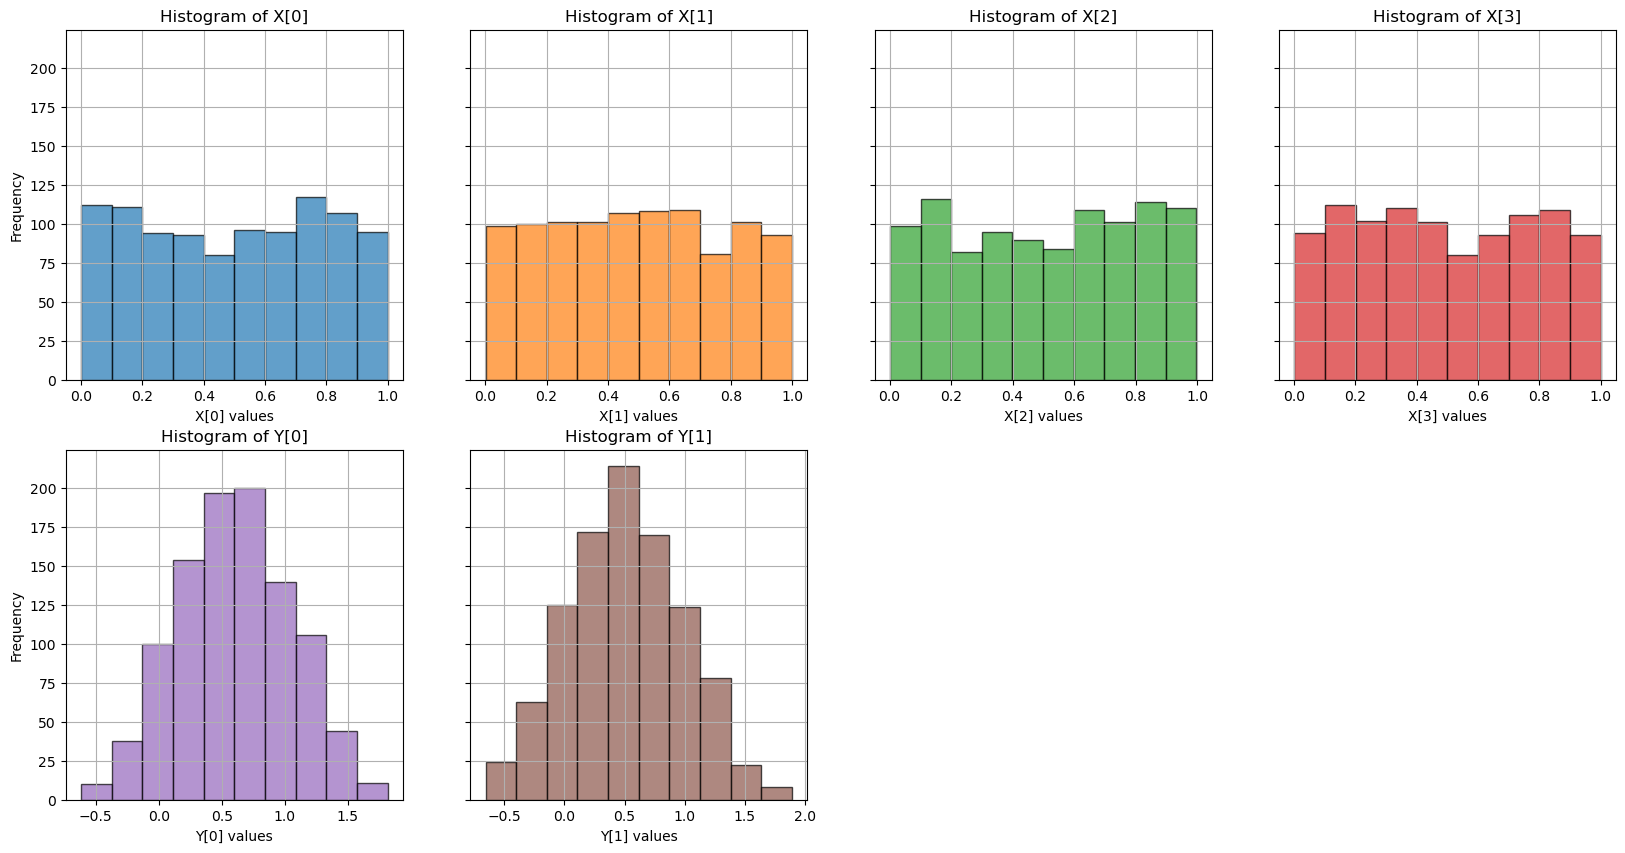

In [2]:
dataset = enabol.AffineDataset(num_samples=1000, use_bias=False)
dataset.plot()
dataset.plot_histogram()
print(dataset)

# Get the data
X, Y = dataset.get()

In [3]:
model = enabol.LinearBlockModel(dataset=dataset, num_hidden=[dataset.A.shape[0]], 
                               activation=None, use_batchnorm=False, verbose=True, 
                               use_bias=False, seed=0)
model.summary()

[INFO] - Building model with input shape (4,) and output shape (2,)
[INFO] - Added Dense layer dense0 with 2 units


Model: "LinearBlockModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model_input (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense0 (Dense)                  │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

## BASELINE: Train model with normal dataset just to make sure it works

In [4]:
# Controller and metrics
from enabol import Controller, MetricsConfig

controller = Controller.from_str(None, chi=1.5, curvature_ema_rho=0.05)
metrics = MetricsConfig(
    profiles=("core", "geometry", "stability", "teacher"),
    reference_A=dataset.A,
)
print(controller)
print(metrics)
print(metrics.reference)


CTRL-NONE(
  α = 1
  θ̇ = θ̇_raw
  χ=1.5 | ρ=0.05 | ε=1e-12 | α∈[0, 1]
)
╔════════════════════════════════════════════════════════════════════╗
║ MetricsConfig                                                      ║
╟───────────────────────────────┬────────────────────────────────────╢
║ Setting                       │ value                              ║
╟───────────────────────────────┼────────────────────────────────────╢
║ profiles                      │ core, geometry, stability, teacher ║
║ fields                        │ 27                                 ║
║ compute_analytic_hessian      │ ● True                             ║
║ requires_hessian              │ ● True                             ║
║ requires_teacher              │ ● True                             ║
║ requires_quantization_metrics │ ● False                            ║
║ reference_A                   │ [2, 4]                             ║
║ include_fields                │ []                                 ║
║ ex


Training LinearBlockModel
[Loop]
  epochs=100 | batch_size=32 | shuffle=True
  loss=half_mse | η=0.05
[Controller]
  CTRL-NONE
  α = 1
  θ̇ = θ̇_raw
  χ=1.5 | η=0.05 | ρ=0.05 | ε=1e-12 | α∈[0, 1]
[Telemetry]
  profiles=core, geometry, stability, teacher | fields=27 | analytic_hessian=True | reference_A=(2, 4)
[Precision]
  PrecisionDict: disabled
---------------------------------------------------------------
Epoch 1/100: loss=0.218972, grad=2.661e-01, C=2.518e+01, alpha_would=1.000
Epoch 2/100: loss=0.246040, grad=3.672e-01, C=1.511e+01, alpha_would=1.000
Epoch 3/100: loss=0.057249, grad=1.845e-01, C=2.721e+01, alpha_would=1.000
Epoch 4/100: loss=0.046678, grad=1.591e-01, C=2.769e+01, alpha_would=1.000
Epoch 5/100: loss=0.017897, grad=6.659e-02, C=1.707e+01, alpha_would=1.000
Epoch 6/100: loss=0.068960, grad=1.481e-01, C=1.476e+01, alpha_would=1.000
Epoch 7/100: loss=0.037869, grad=1.047e-01, C=2.182e+01, alpha_would=1.000
Epoch 8/100: loss=0.023181, grad=8.172e-02, C=1.395e+01, alph

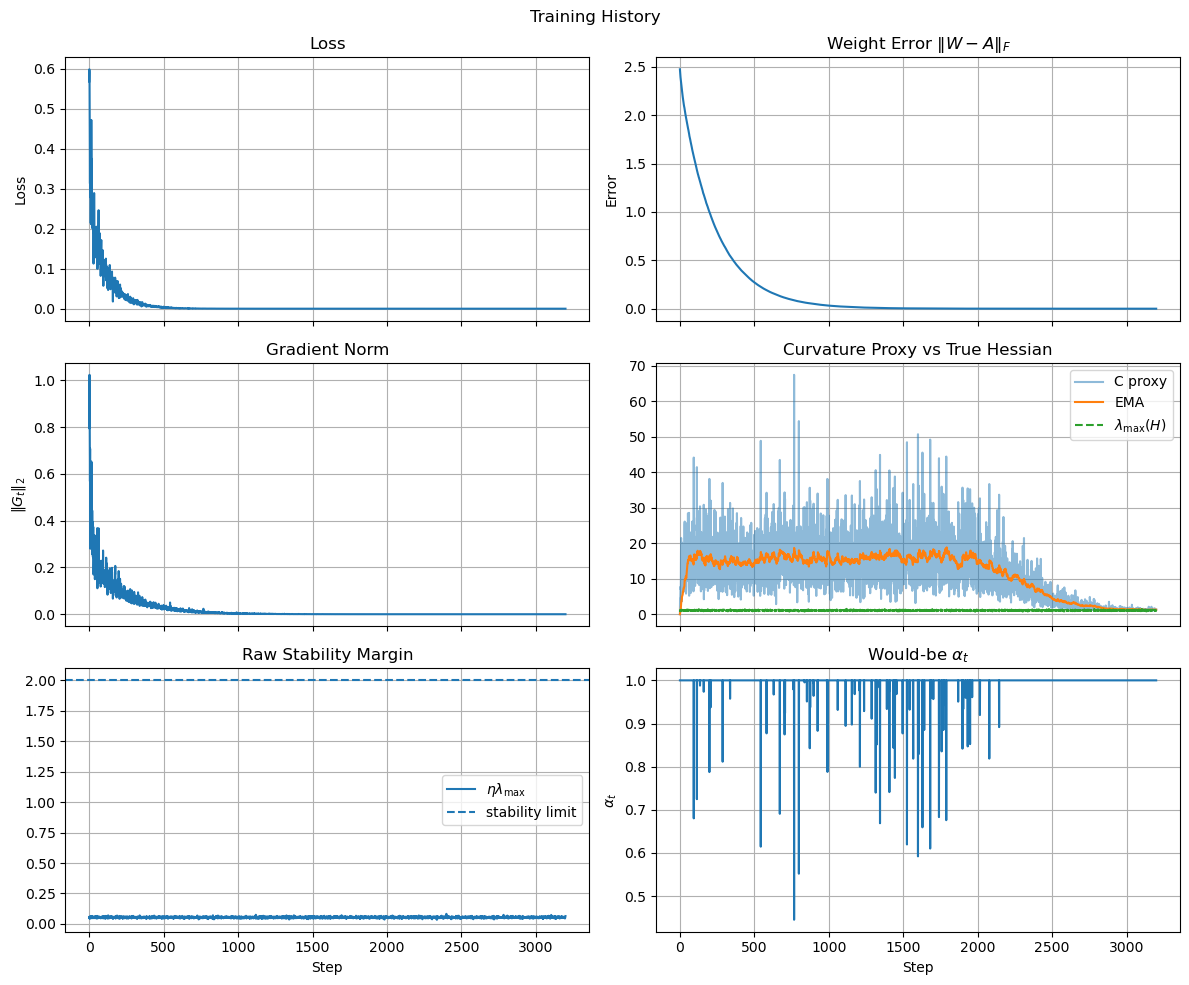

In [5]:
h = model.train_instrumented(
    X,
    Y,
    epochs=100,
    batch_size=32, #dataset.num_samples,  # Full-batch for clean Hessian metrics
    learning_rate=0.05,
    loss_mode="half_mse",
    controller=controller,
    metrics=metrics,
)
print(h)
h.plot_results(title="Training History")


## TEST1: Now reinitialize the model weights, and train first with normal dataset and later with drifted dataset (without controller). 
Expected result: the model should learn first, then with the drifted, go nuts and diverge.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform

Training LinearBlockModel
[Loop]
  epochs=20 | batch_size=1000 | shuffle=True
  loss=half_mse | η=0.5
[Controller]
  CTRL-NONE
  α = 1
  θ̇ = θ̇_raw
  χ=1.5 | η=0.5 | ρ=0.05 | ε=1e-12 | α∈[0, 1]
[Telemetry]
  profiles=legacy-full | fields=40 | analytic_hessian=True
[Precision]
  PrecisionDict: disabled
---------------------------------------------------------------
Epoch 1/20: loss=0.568637, grad=8.582e-01, C=0.000e+00, alpha_would=1.000
Epoch 2/20: loss=0.293852, grad=4.341e-01, C=1.041e+00, alpha_would=1.000
Epoch 3/20: loss=0.220074, grad=2.606e-01, C=9.551e-01, alpha_would=1.000
Epoch 4/20: loss=0.190811, grad=1.991e-01, C=7.402e-01, alpha_would=1.000
Epoch 5/20: loss=0.172275, grad=1.772e-01, C=4.548e-01, alpha_would=1.000
Epoch 6/20: loss=0.157094, grad=1.664e-01, C=2.485e-01, alpha_would=1.000
Epoch 7/20: loss=0.143594, grad=1.584e-01, C=1.445e-01, alpha_would=1.000
Epoch 8/20: loss=0.131330, grad=1.5

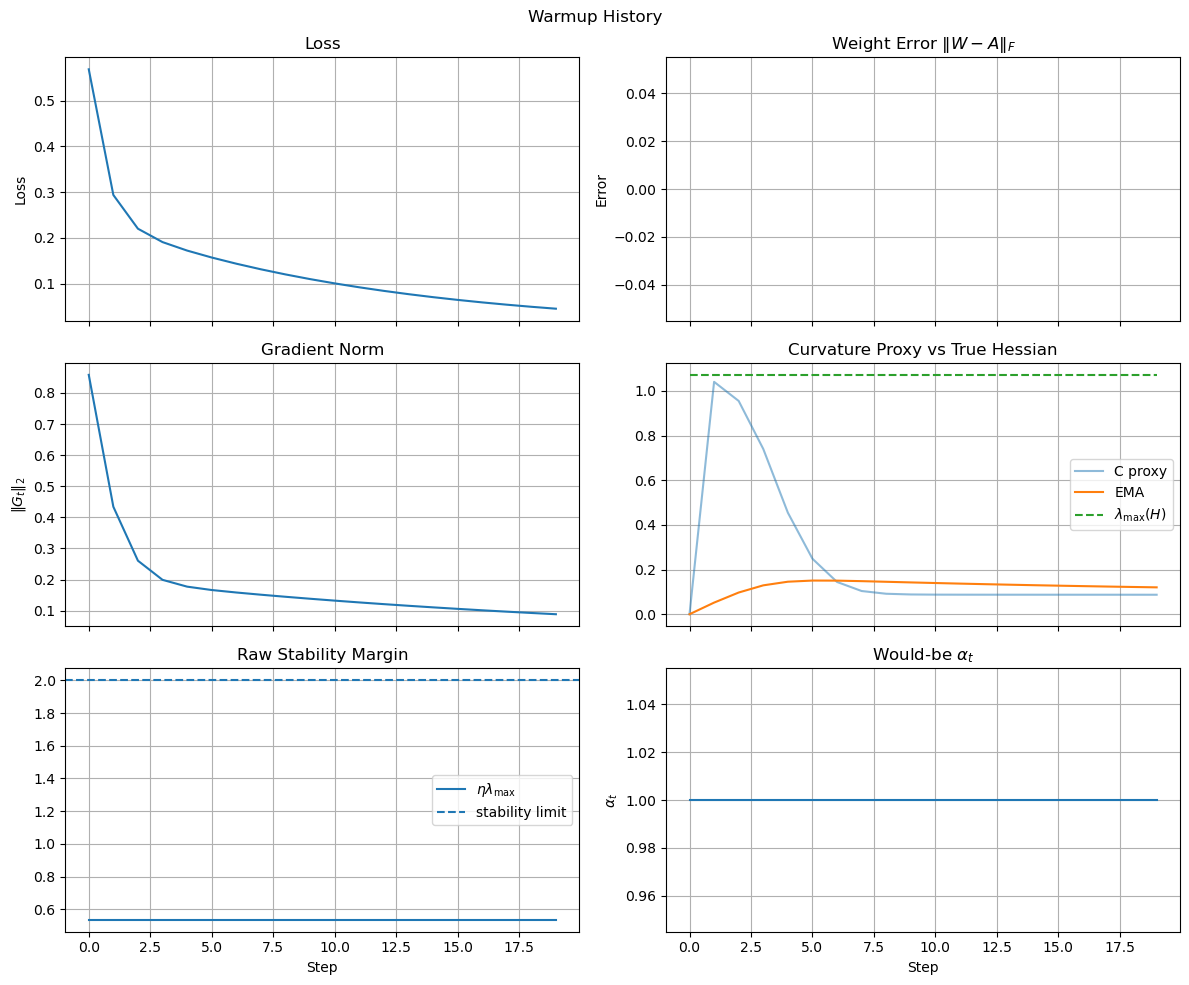

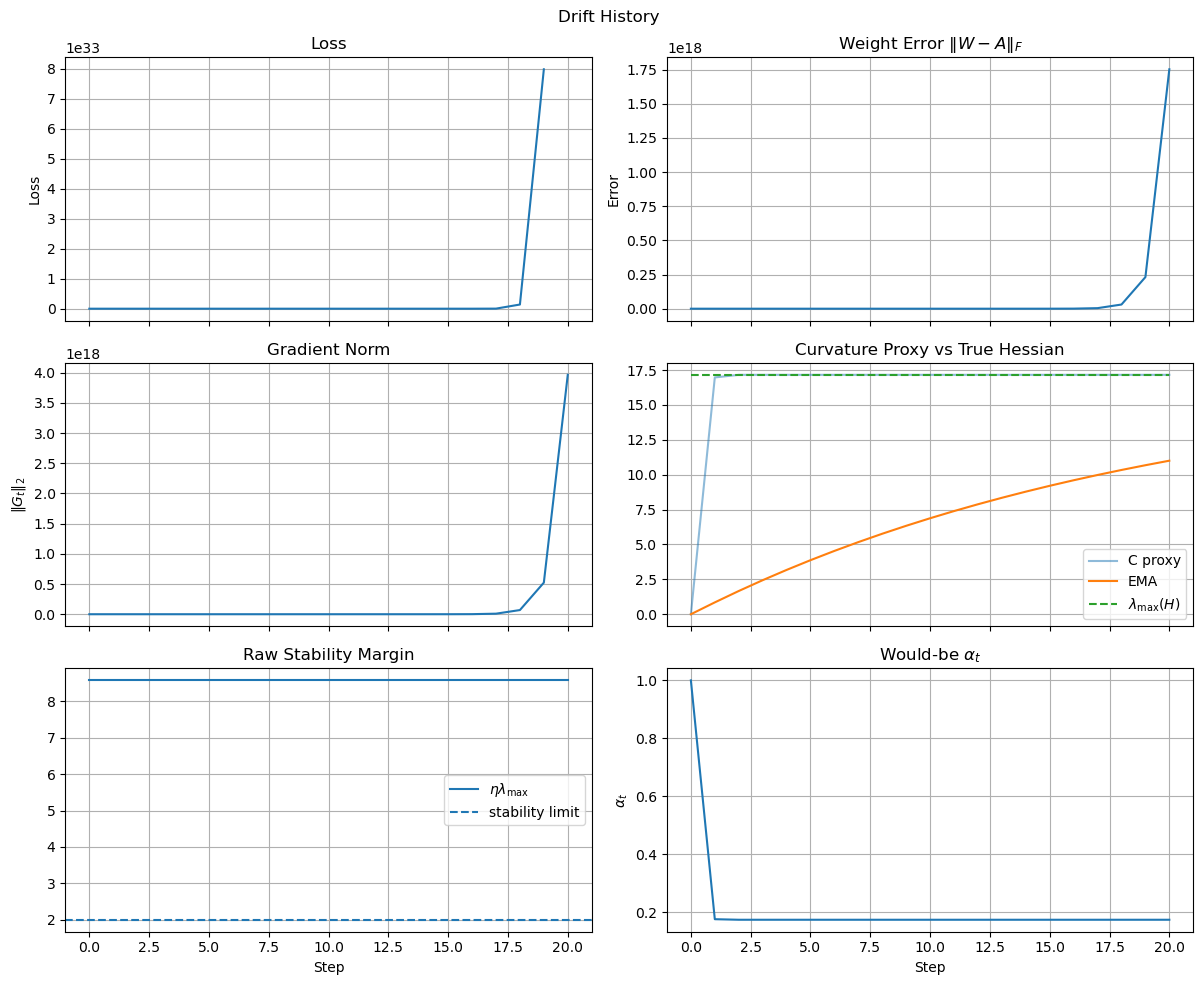

In [6]:
# Reinit
model.reinitialize_weights()

# Phase 1: nominal warmup
h_nom = model.train_instrumented(
    X,
    Y,
    epochs=20,
    batch_size=len(X),
    learning_rate=0.5,
    controller=controller,
)

# Phase 2: sensor gain drift
gamma = 4.0
Xd = gamma * X
Yd = Y  # important: target remains clean
metrics_drift = MetricsConfig(profiles=("core", "geometry", "stability", "teacher"), reference_A=dataset.A / gamma)

h_drift = model.train_instrumented(
    Xd,
    Yd,
    epochs=100,
    batch_size=len(Xd),
    learning_rate=0.5,
    controller=controller,
    metrics=metrics_drift,
)

h_nom.plot_results(title="Warmup History")
h_drift.plot_results(title="Drift History")


## Test3: Same as before, but now we DO activate the controller.
Expected result: the model should learn first, then with the drifted, the controller should kick in and prevent divergence. The loss might be higher than before, but it should not diverge.

[INFO] - Reinitialized kernel for layer dense0 with initializer GlorotUniform

Training LinearBlockModel
[Loop]
  epochs=20 | batch_size=1000 | shuffle=True
  loss=half_mse | η=0.5
[Controller]
  CTRL-NONE
  α = 1
  θ̇ = θ̇_raw
  χ=1.5 | η=0.5 | ρ=0.05 | ε=1e-12 | α∈[0, 1]
[Telemetry]
  profiles=core, geometry, stability, teacher | fields=27 | analytic_hessian=True | reference_A=(2, 4)
[Precision]
  PrecisionDict: disabled
---------------------------------------------------------------
Epoch 1/20: loss=0.568637, grad=8.582e-01, C=0.000e+00, alpha_would=1.000
Epoch 2/20: loss=0.293852, grad=4.341e-01, C=1.041e+00, alpha_would=1.000
Epoch 3/20: loss=0.220074, grad=2.606e-01, C=9.551e-01, alpha_would=1.000
Epoch 4/20: loss=0.190811, grad=1.991e-01, C=7.402e-01, alpha_would=1.000
Epoch 5/20: loss=0.172275, grad=1.772e-01, C=4.548e-01, alpha_would=1.000
Epoch 6/20: loss=0.157094, grad=1.664e-01, C=2.485e-01, alpha_would=1.000
Epoch 7/20: loss=0.143594, grad=1.584e-01, C=1.445e-01, alpha_wou

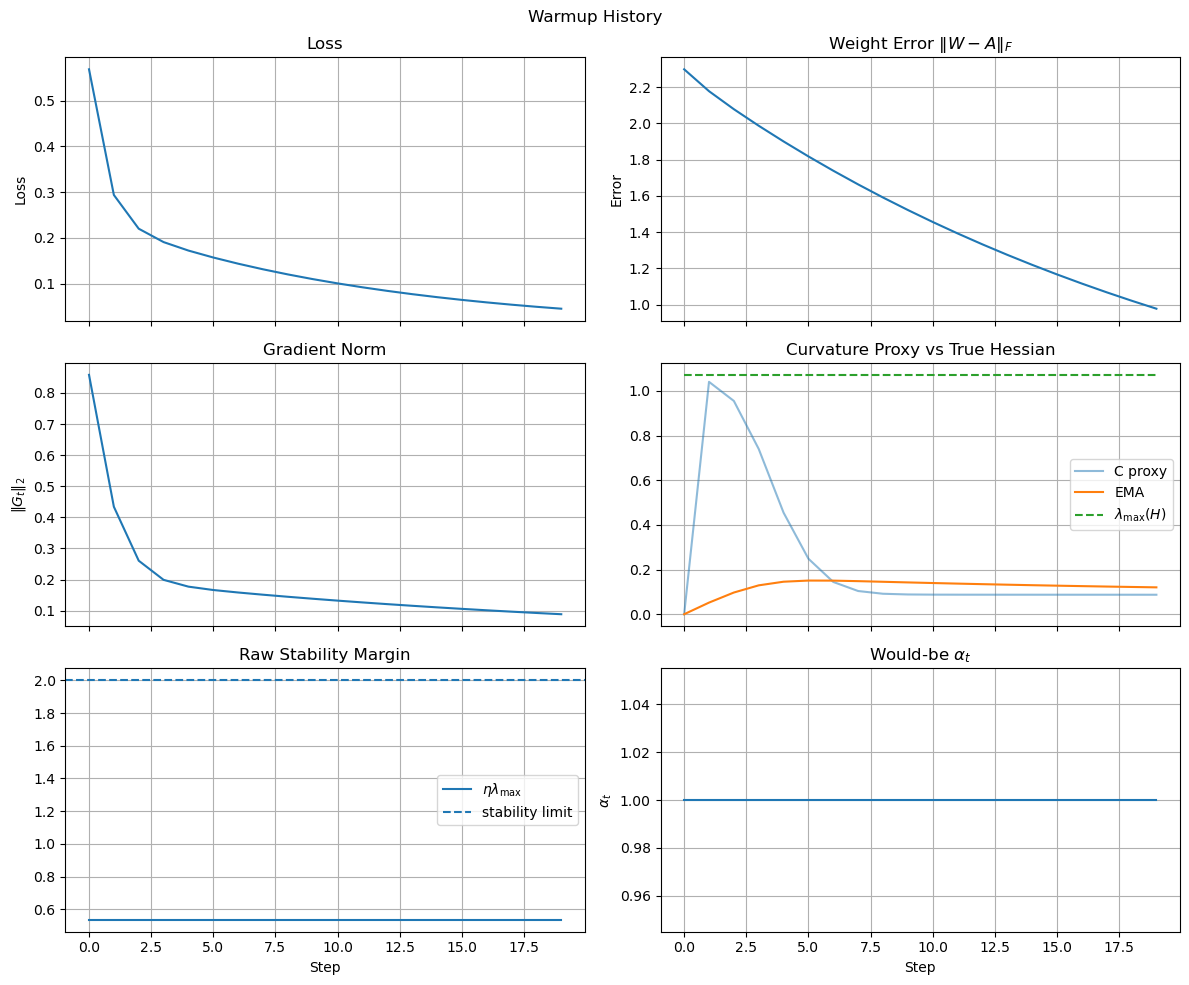

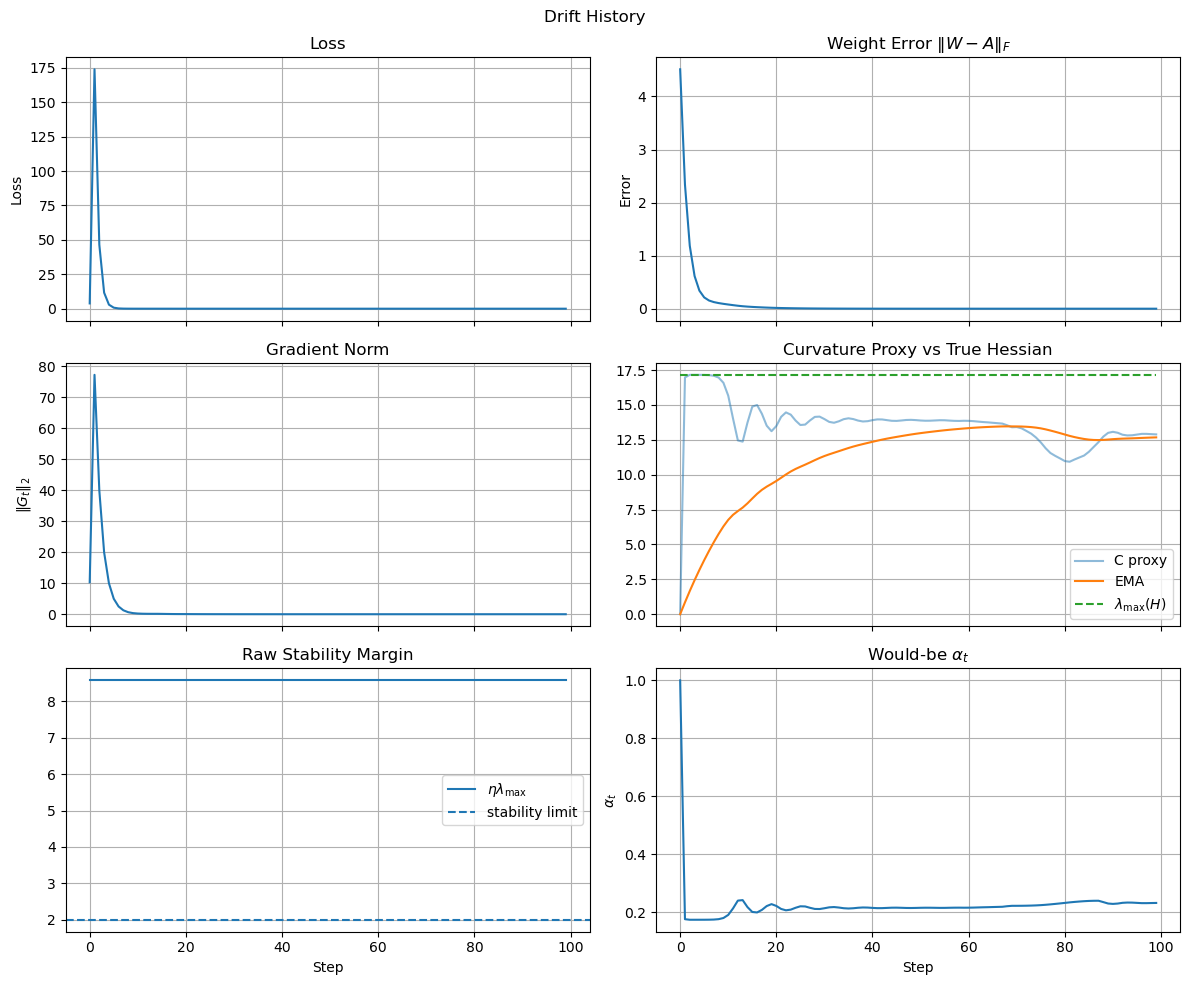

In [7]:
# Reinit
model.reinitialize_weights()

# Phase 1: nominal warmup
h_nom = model.train_instrumented(
    X,
    Y,
    epochs=20,
    batch_size=len(X),
    learning_rate=0.5,
    controller=controller,
    metrics=metrics,
)

controller_linear = Controller.from_str("gt-order-0", chi=1.5, curvature_ema_rho=0.05)

# Phase 2: sensor gain drift
h_drift = model.train_instrumented(
    Xd,
    Yd,
    epochs=100,
    batch_size=len(Xd),
    learning_rate=0.5,
    controller=controller_linear,
    metrics=metrics_drift,
)

h_nom.plot_results(title="Warmup History")
h_drift.plot_results(title="Drift History")
